In [8]:
dataset_path = "MRI_Images"

In [9]:
import os  # for directories and file operations
import numpy as np #for numerical operations and handling image arrays
import random #for generating random values for augmentation
from PIL import Image,ImageEnhance #For img processing and enhancement

#keras
from tensorflow.keras.models import Sequential #For building the model
from tensorflow.keras.layers import Input,Dense,Flatten,Dropout #For model layers
from tensorflow.keras.preprocessing.image import load_img #For loading the imgs
from tensorflow.keras.optimizers import Adam #For optimizer
from tensorflow.keras.applications import VGG16 #for using VGG16
from sklearn.utils import shuffle #For shuffling the data

In [10]:
#Load the dataset
#directories for training and testing the data
train_dir = "MRI_Images/Training"
test_dir = "MRI_Images/Testing"

#load and shuffle the train data
train_path=[]
train_label=[]

for label in os.listdir(train_dir):
 # print(label)
  for  image in os.listdir(os.path.join(train_dir,label)):
    train_path.append(os.path.join(train_dir,label,image))
    train_label.append(label)
train_path,train_label=shuffle(train_path,train_label)
train_path

#load and shuffle the test data
test_path=[]
test_label=[]

for label in os.listdir(test_dir):
 # print(label)
  for  image in os.listdir(os.path.join(test_dir,label)):
    test_path.append(os.path.join(test_dir,label,image))
    test_label.append(label)
test_path,test_label=shuffle(test_path,test_label)
test_path

['MRI_Images/Testing\\pituitary\\Te-pi_170.jpg',
 'MRI_Images/Testing\\glioma\\Te-gl_225.jpg',
 'MRI_Images/Testing\\glioma\\Te-gl_344.jpg',
 'MRI_Images/Testing\\notumor\\Te-no_37.jpg',
 'MRI_Images/Testing\\meningioma\\Te-me_66.jpg',
 'MRI_Images/Testing\\notumor\\Te-no_235.jpg',
 'MRI_Images/Testing\\pituitary\\Te-pi_53.jpg',
 'MRI_Images/Testing\\pituitary\\Te-pi_385.jpg',
 'MRI_Images/Testing\\pituitary\\Te-pi_307.jpg',
 'MRI_Images/Testing\\pituitary\\Te-pi_60.jpg',
 'MRI_Images/Testing\\pituitary\\Te-pi_22.jpg',
 'MRI_Images/Testing\\meningioma\\Te-me_119.jpg',
 'MRI_Images/Testing\\pituitary\\Te-pi_299.jpg',
 'MRI_Images/Testing\\pituitary\\Te-pi_209.jpg',
 'MRI_Images/Testing\\pituitary\\Te-pi_177.jpg',
 'MRI_Images/Testing\\pituitary\\Te-pi_181.jpg',
 'MRI_Images/Testing\\notumor\\Te-no_328.jpg',
 'MRI_Images/Testing\\pituitary\\Te-pi_97.jpg',
 'MRI_Images/Testing\\notumor\\Te-no_108.jpg',
 'MRI_Images/Testing\\notumor\\Te-no_126.jpg',
 'MRI_Images/Testing\\notumor\\Te-no_263

In [39]:
import os

train_dir = "MRI_Images/Training"
class_names = sorted(os.listdir(train_dir))
class_to_index = {name: i for i, name in enumerate(class_names)}

print("Class names (sorted):", class_names)
print("Class to index mapping:", class_to_index)

Class names (sorted): ['glioma', 'meningioma', 'notumor', 'pituitary']
Class to index mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


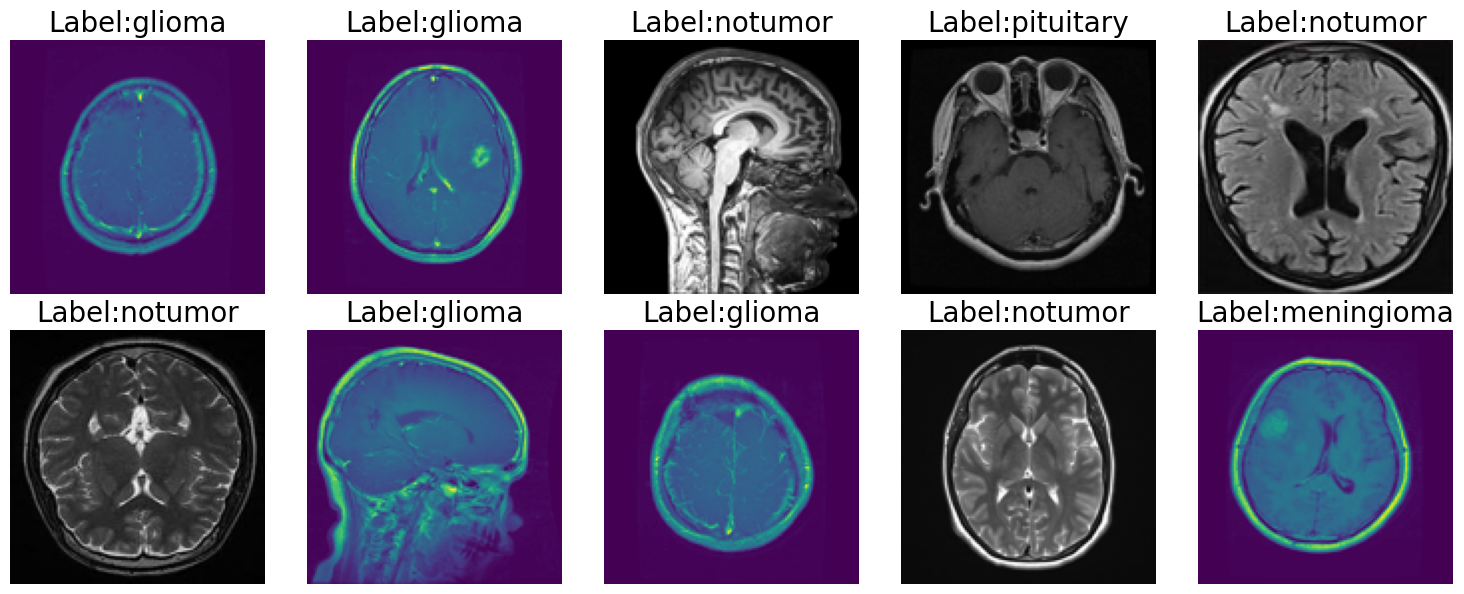

In [11]:
#Data Visualization
import random
import matplotlib.pyplot as plt


#Select random indcies for 10 images
random_indices=random.sample(range(len(train_path)),10)
random_indices

#Create a figure to display imgs in a row or 2 rows
fig, axes=plt.subplots(2,5,figsize=(15,6))
axes=axes.ravel()

#Loop through the random indices and display images
for i,idx in enumerate (random_indices):
  img_path=train_path[idx]
  img=Image.open(img_path)
  img=img.resize((128,128))


  #Display Images
  axes[i].imshow(img)
  axes[i].axis("off")
  axes[i].set_title(f"Label:{train_label[idx]}",fontsize=20) #this gives label for each img
plt.tight_layout()
plt.show()

In [12]:
#Image Preprocessing(Helper Functions)
#Image Augmentation Function
def augment_image(image):
  image=Image.fromarray(np.uint8(image))
  image=ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
  image=ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
  image=np.array(image)/255.0
  return image

#Load images and apply augmentation
def open_images(paths):
  images=[]
  for path in paths:
    img=load_img(path,target_size=(IMAGE_SIZE,IMAGE_SIZE))
    img=augment_image(img)
    images.append(img)
  return np.array(images)

#Encoder labels(Converts label names into integers)
# Create this ONCE globally
class_names = sorted(os.listdir(train_dir))
class_to_index = {name: i for i, name in enumerate(class_names)}

def encode_label(labels):
    return np.array([class_to_index[l] for l in labels])

#Data Generator for batching
def datagen(paths, labels, batch_size=12):
    while True:
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i+batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i+batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels

In [13]:
#Model Architecture RGB everyimg(128,128,3)  128- height, width  3-R,G,B
IMAGE_SIZE=128
base_model=VGG16(input_shape=(IMAGE_SIZE,IMAGE_SIZE,3),include_top=False,weights='imagenet')

#Freeze all the layers of VGG16 base model
for layer in base_model.layers:
  layer.trainable=False

#Set only the last few layers
base_model.layers[-2].trainable=True
base_model.layers[-3].trainable=True
base_model.layers[-4].trainable=True


#Build Model
model=Sequential()
model.add(Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3)))#Input layer
model.add(base_model)  #VGG16 model
model.add(Flatten())   #Flatten layer
model.add(Dropout(0.3)) #Dropout layer

model.add(Dense(128,activation='relu')) #Dense layer
model.add(Dropout(0.2)) #Dropout layer
model.add(Dense(len(os.listdir(train_dir)),activation='softmax')) #Output layer

#compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['sparse_categorical_accuracy'])

#Parameters
batch_size=20
steps=int(len(train_path)/batch_size)
epochs=5 #this trains the model 5 times giving high accuracy

#train model
history = model.fit(
    datagen(train_path, train_label, batch_size=batch_size),
    steps_per_epoch=steps,
    epochs=5
)

Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 442s 2s/step - loss: 0.4837 - sparse_categorical_accuracy: 0.8093
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 347s 1s/step - loss: 0.2504 - sparse_categorical_accuracy: 0.9050
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 276s 987ms/step - loss: 0.1742 - sparse_categorical_accuracy: 0.9316
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 273s 974ms/step - loss: 0.1270 - sparse_categorical_accuracy: 0.9534
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - loss: 0.0756 - sparse_categorical_accuracy: 0.9700


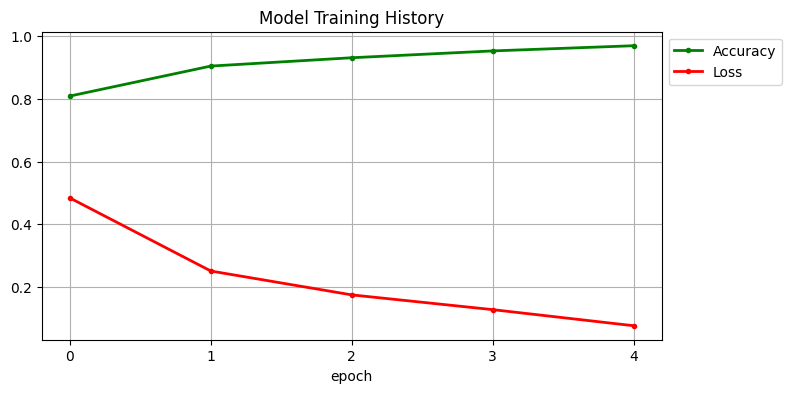

In [29]:
   #Train and Val Plots
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

test_images = open_images(test_path)
test_label_encoded = encode_label(test_label)

test_predictions = model.predict(test_images)

print("Classification Report:")
print(classification_report(test_label_encoded, np.argmax(test_predictions, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 994ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.72      0.83       400
           1       0.82      0.95      0.88       400
           2       0.90      1.00      0.95       400
           3       0.98      0.97      0.98       400

    accuracy                           0.91      1600
   macro avg       0.92      0.91      0.91      1600
weighted avg       0.92      0.91      0.91      1600



Confusion Matrix:
[[287  72  35   6]
 [  7 381  10   2]
 [  0   0 400   0]
 [  0   9   1 390]]


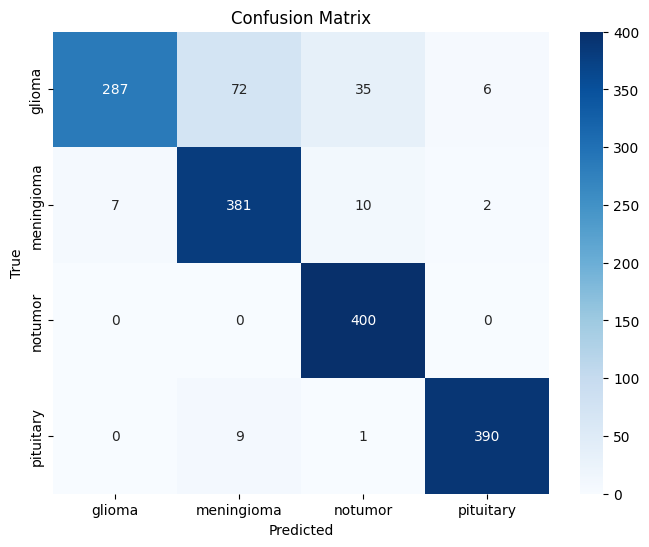

In [31]:
#Confusion matrix
conf_matrix = confusion_matrix(test_label_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=os.listdir(train_dir),
            yticklabels=os.listdir(train_dir))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

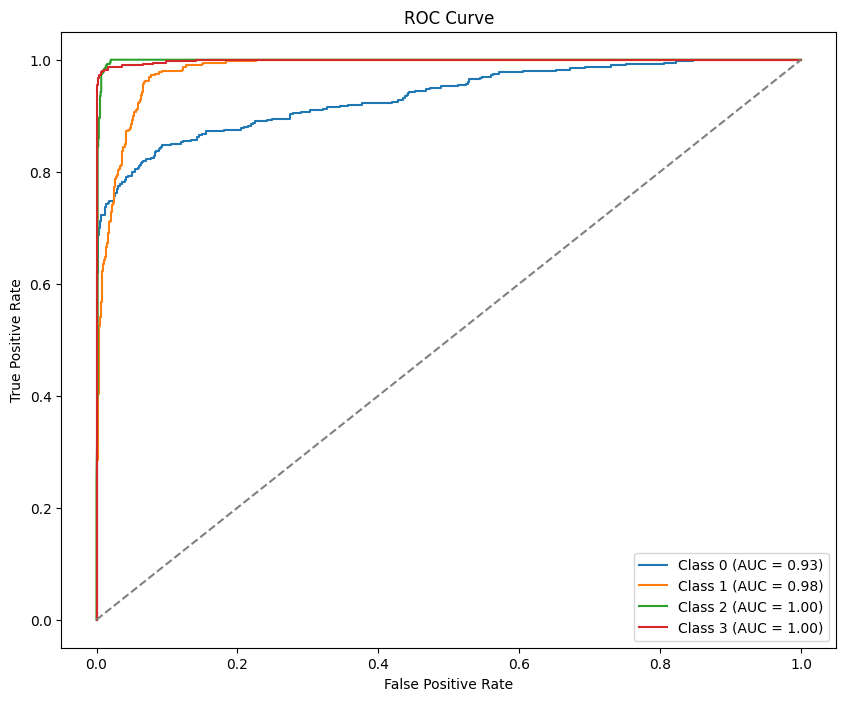

In [32]:
#ROC curve plot
test_images = open_images(test_path)
test_label_encoded = encode_label(test_label)

# The confusion matrix part was already handled in the previous cell
# and the line below caused a SyntaxError. It's removed.
# xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir)

# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_label_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray') # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [38]:
model.save("model.h5")

In [35]:
from tensorflow.keras.models import load_model
#Load the trained model
model = load_model("model.h5")

In [37]:
from keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']  # exact order from training

def detect_and_display(image_path, model):
    try:
        # Load image
        img = load_img(image_path, target_size=(128, 128))
        img_array = img_to_array(img)
        img_array = img_array / 255.0   # Important normalization
        img_array = np.expand_dims(img_array, axis=0)

        # Prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions)
        confidence_score = np.max(predictions)

        # Determine class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumour"
        else:
            result = f"Tumour: {class_labels[predicted_class_index]}"

        # Display
        plt.imshow(load_img(image_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score*100:.2f}%)")
        plt.show()

        return result

    except Exception as e:
        print("Error in processing the image:", str(e))
        return None